Տարածության մեջ տրված է ուղղորդ կորը

$$
\vec{r}(u)=\left(u^2+1\right)\vec{i}+\left(u^3+2\right)\vec{j}+\left(2u-3\right)\vec{k},
\qquad 0.2\le u\le3 :
$$

Դիտարկվում է տուփաձև մակերևույթ, որի լայնական հատույթը հանդիսանում է քառանկյուն ABCD`

$$
A(-3.25,-1.25),\qquad
B(-2.25,1.75),\qquad
C(1.75,1.75),\qquad
D(3.75,-2.25).
$$

Տրված քառանկյան գագաթների միջոցով սահմանվում են համապատասխան տարածական կորերը`

$$
P_i(u)=\vec{r}(u)+x_i\,\vec{e}_0(u)+z_i\,\vec{g}_0(u),
\qquad i=1,2,3,4
$$

որտեղ $(x_i,z_i)$ քառանկյան համապատասխան գագաթների կոորդինատներն են, իսկ $\vec e_0(u)$ և $\vec g_0(u)$ վեկտորները որոշվում են ուղղորդ կորի Ֆրենեի եռանիստի միջոցով`

$$
\vec{e}_0(u)=
\frac{\left(\vec r'(u)\times \vec r''(u)\right)\times \vec r'(u)}
{\left|\vec r'(u)\times \vec r''(u)\right|\cdot\left|\vec r'(u)\right|},
$$

$$
\vec{g}_0(u)=
\frac{\vec r'(u)\times \vec r''(u)}
{\left|\vec r'(u)\times \vec r''(u)\right|}:
$$

Ստացված $ P_1(u),P_2(u),P_3(u),P_4(u) $ կորերը հանդիսանում են մակերևույթի սահմանային կորեր։

Տուփաձև մակերևույթի նիստերը ստացվում են հարևան կորերի միջև գծային ինտերպոլացիայով`

$$
\vec{\rho}_k(u,v)=(1-v)P_k(u)+vP_{k+1}(u),
\qquad k=1,2,3,4:
$$

Պահանջվում է կառուցել տուփաձև մակերևույթի

$$
\rho_k(u,v), \qquad k=1,\ldots,4
$$

նիստերի պարամետրական հավասարումները, ինչպես նաև կառուցել տուփաձև մակերևույթը որպես այդ նիստերի միավորում`

$$
S=\bigcup_{k=1}^{4}\rho_k(u,v)
$$

և իրականացնել դրանց գրաֆիկական պատկերումը։

In [30]:
import numpy as np
import sympy as sp
import plotly.graph_objects as go

In [31]:
u, v = sp.symbols('u v', real=True)

r_u = sp.Matrix([
    u**2 + 1,
    u**3 + 2,
    2*u - 3
])

r_prime = sp.diff(r_u, u)
r_double_prime = sp.diff(r_prime, u)

In [32]:
cross_vec = r_prime.cross(r_double_prime)
norm_cross = sp.sqrt(cross_vec.dot(cross_vec))
norm_r_prime = sp.sqrt(r_prime.dot(r_prime))

g0_u = sp.simplify(cross_vec / norm_cross)
e0_u = sp.simplify(cross_vec.cross(r_prime) / (norm_cross * norm_r_prime))

In [33]:
A = (-3.25, -1.25)
B = (-2.25,  1.75)
C = ( 1.75,  1.75)
D = ( 3.75, -2.25)

vertices = [A, B, C, D]

In [34]:
P_exprs = [
    sp.simplify(r_u + x_i * e0_u + z_i * g0_u)
    for (x_i, z_i) in vertices
]

P_closed = P_exprs + [P_exprs[0]]

In [35]:
rho_exprs = [
    sp.simplify((1 - v) * P_closed[k] + v * P_closed[k + 1])
    for k in range(4)
]

In [36]:
print("r(u) =")
sp.pprint(r_u)

print("\nr'(u) =")
sp.pprint(r_prime)

print("\nr''(u) =")
sp.pprint(r_double_prime)

print("\ne0(u) =")
sp.pprint(e0_u)

print("\ng0(u) =")
sp.pprint(g0_u)

for i, P_i in enumerate(P_exprs, start=1):
    print(f"\nP_{i}(u) =")
    sp.pprint(P_i)

for i, rho_i in enumerate(rho_exprs, start=1):
    print(f"\nρ_{i}(u,v) =")
    sp.pprint(rho_i)

r(u) =
⎡ 2     ⎤
⎢u  + 1 ⎥
⎢       ⎥
⎢ 3     ⎥
⎢u  + 2 ⎥
⎢       ⎥
⎣2⋅u - 3⎦

r'(u) =
⎡2⋅u ⎤
⎢    ⎥
⎢   2⎥
⎢3⋅u ⎥
⎢    ⎥
⎣ 2  ⎦

r''(u) =
⎡ 2 ⎤
⎢   ⎥
⎢6⋅u⎥
⎢   ⎥
⎣ 0 ⎦

e0(u) =
⎡                        4                 ⎤
⎢                 4 - 9⋅u                  ⎥
⎢──────────────────────────────────────────⎥
⎢   _______________________________________⎥
⎢  ╱     8        6        4        2      ⎥
⎢╲╱  81⋅u  + 360⋅u  + 216⋅u  + 160⋅u  + 16 ⎥
⎢                                          ⎥
⎢                   ⎛ 2    ⎞               ⎥
⎢               6⋅u⋅⎝u  + 2⎠               ⎥
⎢──────────────────────────────────────────⎥
⎢   _______________________________________⎥
⎢  ╱     8        6        4        2      ⎥
⎢╲╱  81⋅u  + 360⋅u  + 216⋅u  + 160⋅u  + 16 ⎥
⎢                                          ⎥
⎢                    3                     ⎥
⎢              - 18⋅u  - 4⋅u               ⎥
⎢──────────────────────────────────────────⎥
⎢   _______________________________________⎥
⎢  ╱     8   

In [37]:
r_func = sp.lambdify(u, r_u, "numpy")

P_funcs = [
    tuple(sp.lambdify(u, P_i[j], "numpy") for j in range(3))
    for P_i in P_exprs
]

rho_funcs = [
    tuple(sp.lambdify((u, v), rho_i[j], "numpy") for j in range(3))
    for rho_i in rho_exprs
]

In [38]:
def eval_curve(curve_func, u_vals):
    fx, fy, fz = curve_func
    return np.stack([
        np.asarray(fx(u_vals), dtype=float),
        np.asarray(fy(u_vals), dtype=float),
        np.asarray(fz(u_vals), dtype=float)
    ], axis=-1)

def eval_surface(surface_func, U, V):
    fx, fy, fz = surface_func
    return np.stack([
        np.asarray(fx(U, V), dtype=float),
        np.asarray(fy(U, V), dtype=float),
        np.asarray(fz(U, V), dtype=float)
    ], axis=-1)

def add_curve(fig, curve, name, color, width=6):
    fig.add_trace(go.Scatter3d(
        x=curve[:, 0],
        y=curve[:, 1],
        z=curve[:, 2],
        mode='lines',
        line=dict(color=color, width=width),
        name=name
    ))

def add_surface_trace(fig, surf, name, colorscale, opacity=0.8):
    fig.add_trace(go.Surface(
        x=surf[:, :, 0],
        y=surf[:, :, 1],
        z=surf[:, :, 2],
        colorscale=colorscale,
        showscale=False,
        opacity=opacity,
        name=name
    ))

def update_layout(fig, title, width=1000, height=750):
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        ),
        width=width,
        height=height
    )

In [39]:
u_min, u_max = 0.2, 3.0
Nu, Nv = 180, 40

u_vals = np.linspace(u_min, u_max, Nu)
v_vals = np.linspace(0.0, 1.0, Nv)
U, V = np.meshgrid(u_vals, v_vals, indexing="ij")

curve_r = np.array(r_func(u_vals), dtype=float).reshape(3, -1).T
P_curves = [eval_curve(Pf, u_vals) for Pf in P_funcs]
rho_surfaces = [eval_surface(rhof, U, V) for rhof in rho_funcs]

In [40]:
curve_color_map = {
    1: 'red',
    2: 'blue',
    3: 'green',
    4: 'purple'
}

surface_colors = {
    1: 'Reds',
    2: 'Blues',
    3: 'Greens',
    4: 'Purples'
}

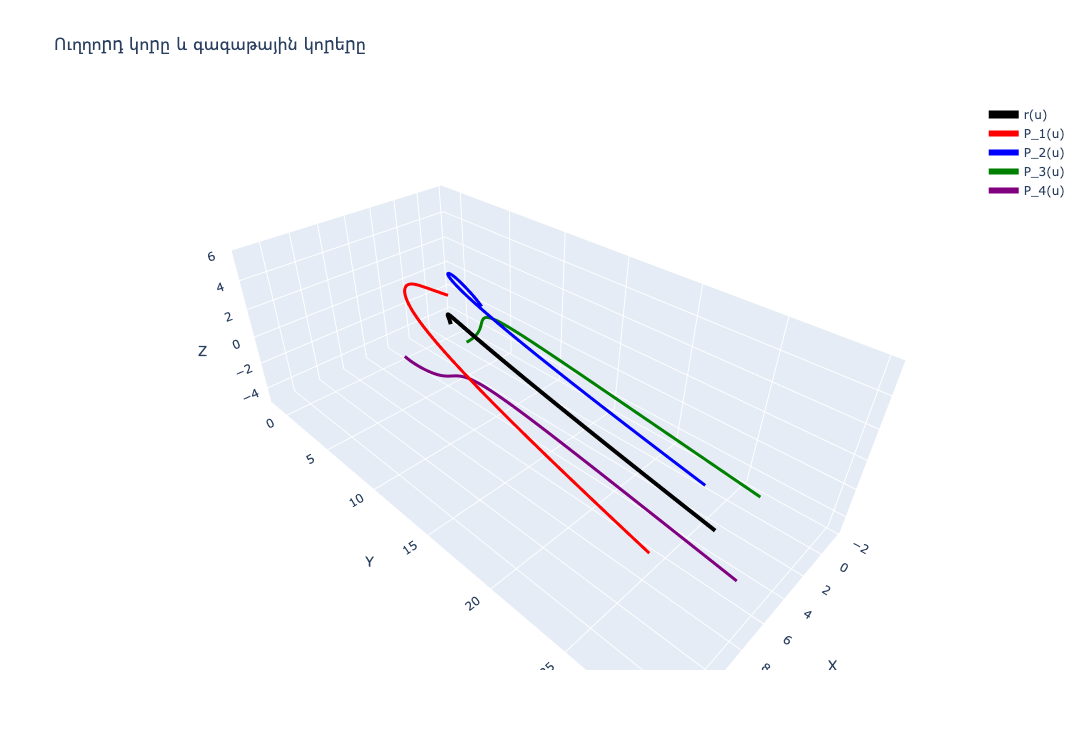

In [41]:
fig_curves = go.Figure()

add_curve(fig_curves, curve_r, 'r(u)', 'black', width=8)

for i, Pc in enumerate(P_curves, start=1):
    add_curve(fig_curves, Pc, f'P_{i}(u)', curve_color_map[i], width=6)

update_layout(fig_curves, 'Ուղղորդ կորը և գագաթային կորերը', 1000, 750)
fig_curves.show()

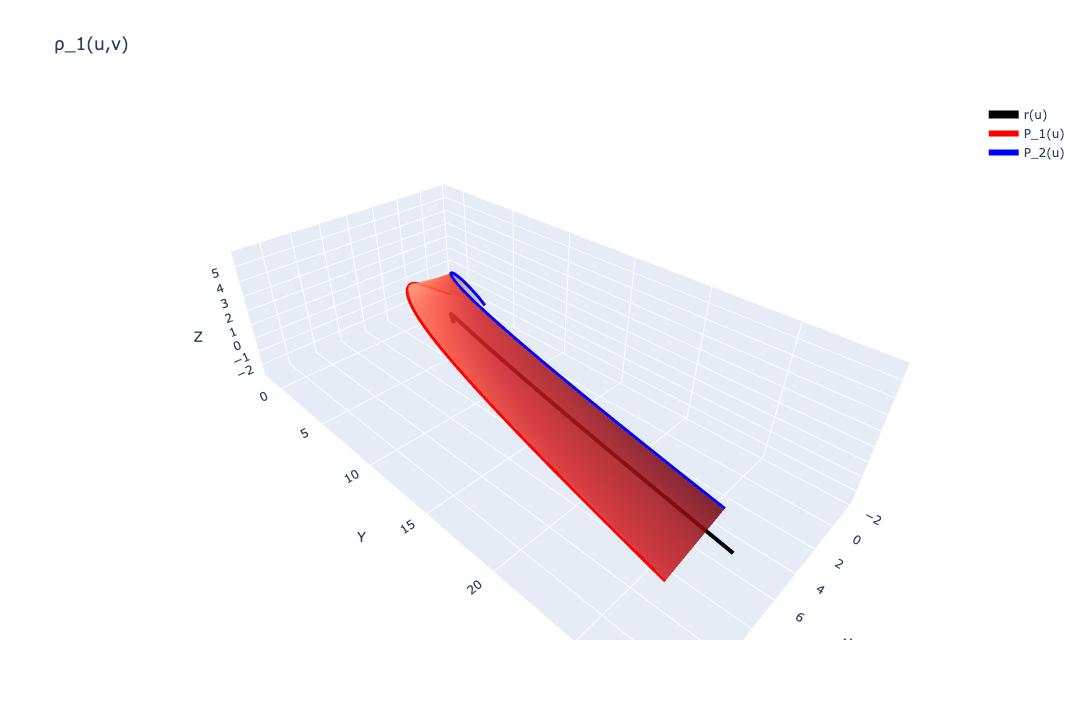

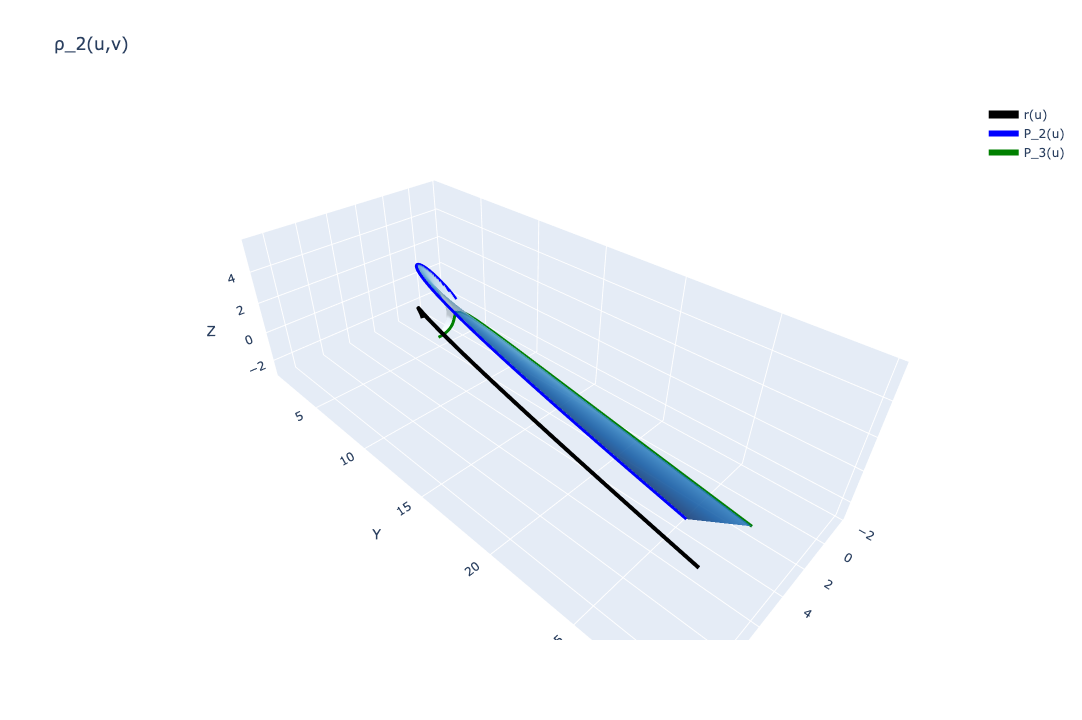

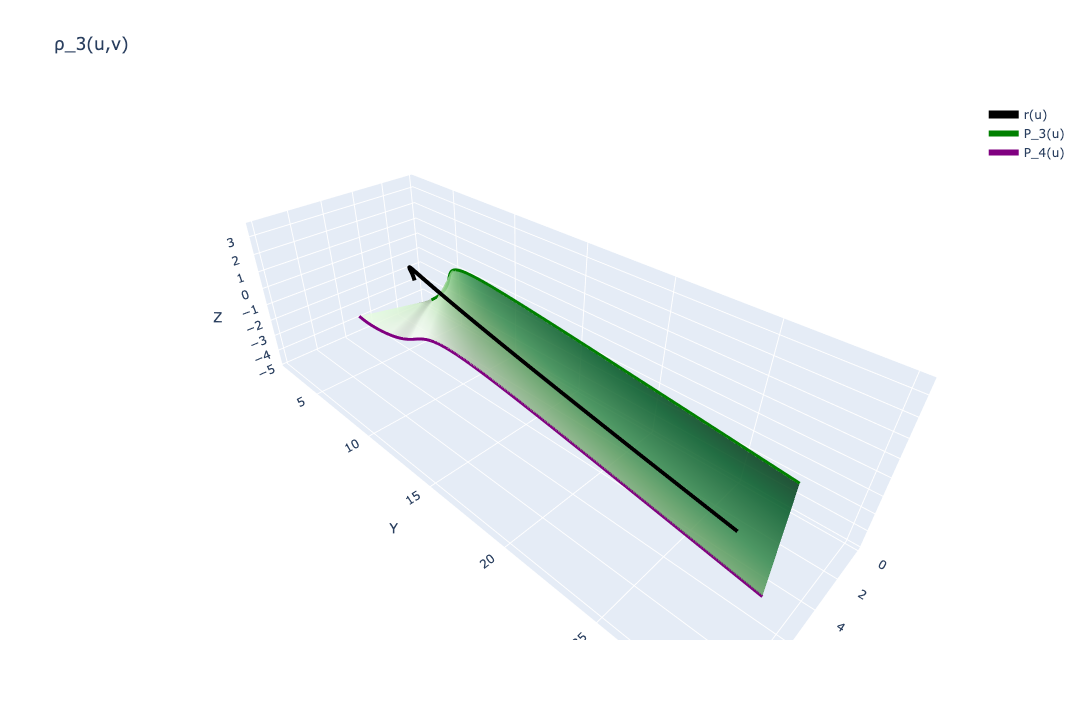

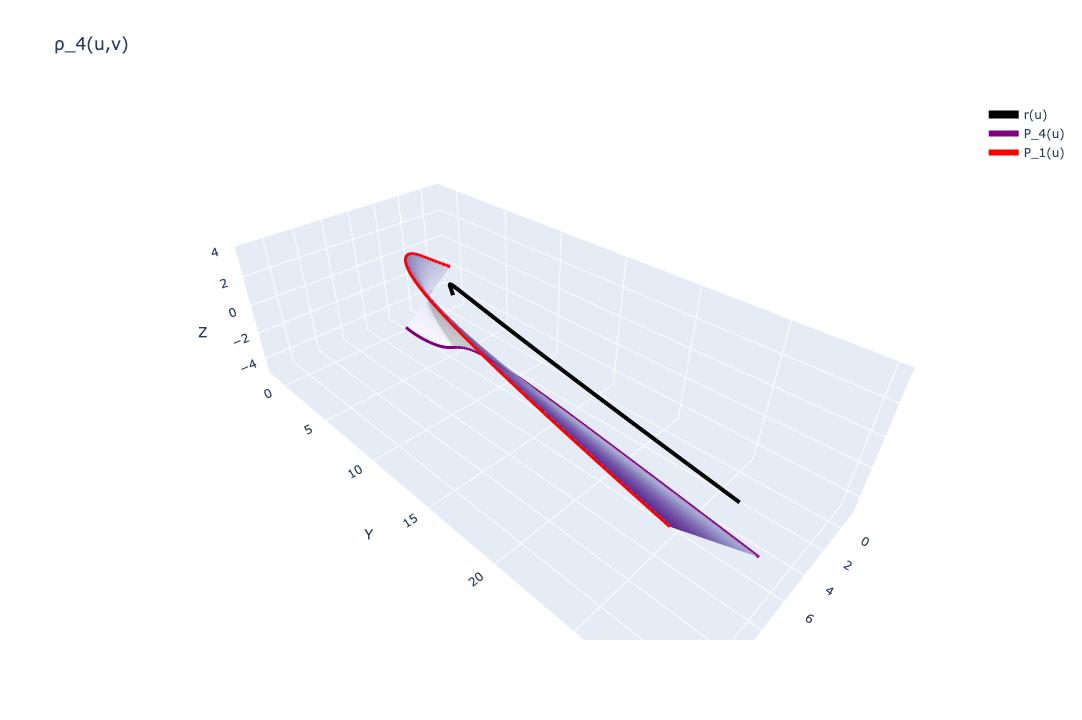

In [42]:
for i, rho_surf in enumerate(rho_surfaces, start=1):
    fig = go.Figure()

    add_surface_trace(fig, rho_surf, f'ρ_{i}(u,v)', surface_colors[i], opacity=0.85)
    add_curve(fig, curve_r, 'r(u)', 'black', width=8)

    next_idx = 1 if i == 4 else i + 1
    add_curve(fig, P_curves[i - 1], f'P_{i}(u)', curve_color_map[i], width=6)
    add_curve(fig, P_curves[i % 4], f'P_{next_idx}(u)', curve_color_map[next_idx], width=6)

    update_layout(fig, f'ρ_{i}(u,v)', 950, 720)
    fig.show()

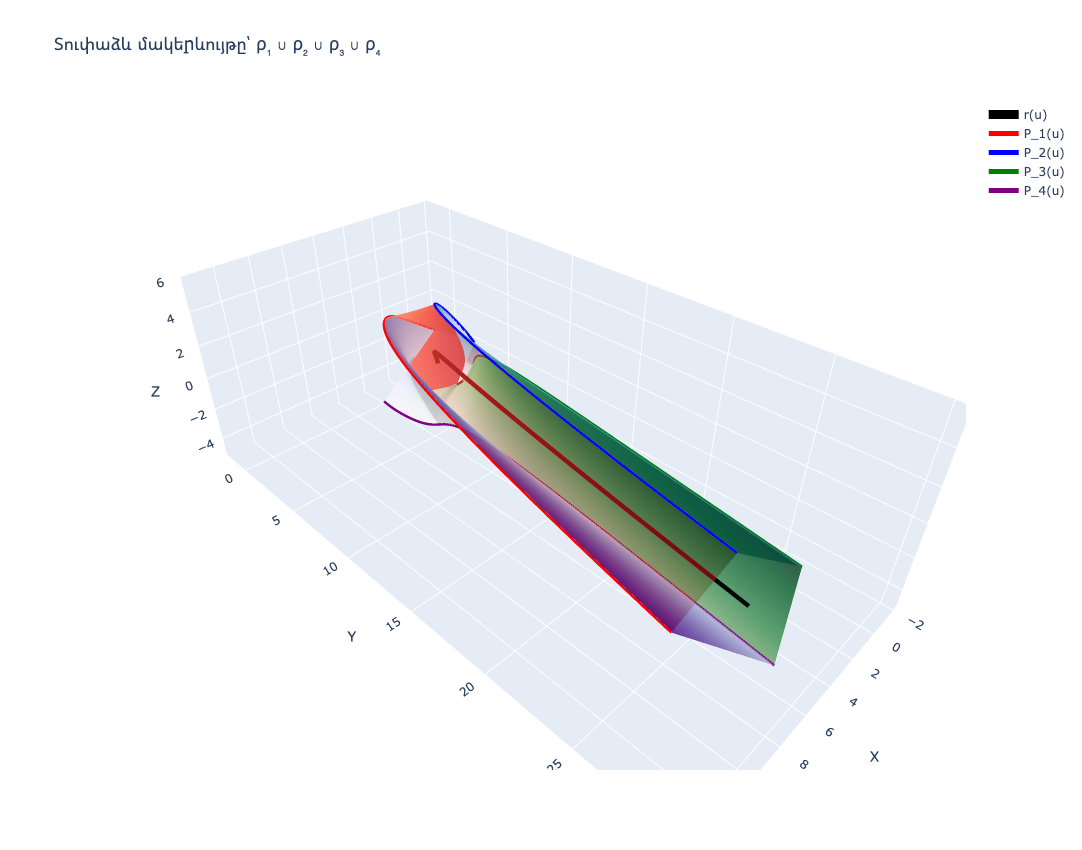

In [43]:
fig_all = go.Figure()

for i, rho_surf in enumerate(rho_surfaces, start=1):
    add_surface_trace(fig_all, rho_surf, f'ρ_{i}(u,v)', surface_colors[i], opacity=0.78)

add_curve(fig_all, curve_r, 'r(u)', 'black', width=9)

for i, Pc in enumerate(P_curves, start=1):
    add_curve(fig_all, Pc, f'P_{i}(u)', curve_color_map[i], width=5)

update_layout(fig_all, 'Տուփաձև մակերևույթը՝ ρ₁ ∪ ρ₂ ∪ ρ₃ ∪ ρ₄', 1150, 850)
fig_all.show()